# Wholesale Channel Analytics — Faire

**Author:** Aryan Bhardwaj · [rearyan.com](https://rearyan.com) · [github.com/aaryanbh96](https://github.com/aaryanbh96)

A start-to-finish analysis of a specialty manufacturer's wholesale channel on Faire — built to turn raw order exports into decisions about which products to bundle, which retailers to re-engage, and where the channel is growing.

> **Note on data:** This portfolio version runs on **synthetic data** generated to match the shape and structure of the real channel (order cadence, retailer mix, product co-occurrence, geographic spread). The real analysis was run on actual order data; **all revenue is shown as an index (mean order = 100), never absolute currency**, and figures contain no confidential information. All analytical methods are unchanged.

### What's inside
- **Data prep & KPIs** — order-level aggregation, revenue/margin, fulfilment speed
- **Growth & retention** — monthly trajectory, new-retailer cohorts, repeat rate
- **Geography** — revenue by state (choropleth)
- **Product analysis** — bestsellers, margins, **basket / co-occurrence analysis** (the insight behind a bundle strategy)
- **Retailer segmentation** — **RFM scoring**, retailer-type classification, repeat-rate by type
- **Action models** — overdue-reorder flagging, reorder revenue scenarios, seasonal & day-of-week patterns, Pareto concentration

### Stack
`pandas` · `numpy` · `matplotlib` · `seaborn` · `plotly` · `itertools` / `collections`

## 0 · Synthetic dataset

Generates a Faire-shaped order export so the notebook runs end-to-end with no external file. Swap this single cell for a real `pd.read_csv(...)` to run on live data.

In [1]:

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# --- Catalog: realistic specialty-tea product mix (public-style names, no internal SKUs) ---
products = [
    ("SKU-101", "Oregon Berry Black Tea, 11.5 fl. oz",   2.95, 4.50),
    ("SKU-102", "Gunpowder Mint Green Tea, 11.5 fl. oz", 2.95, 4.50),
    ("SKU-103", "Cape Town Rooibos, 11.5 fl. oz",        2.95, 4.50),
    ("SKU-201", "English Breakfast Pyramid Sachets",     6.50, 12.00),
    ("SKU-202", "Earl Grey Pyramid Sachets",             6.50, 12.00),
    ("SKU-203", "Jasmine Green Pyramid Sachets",         6.50, 12.00),
    ("SKU-301", "Assam Loose Leaf Eco-Refill",           8.00, 15.00),
    ("SKU-302", "Sencha Loose Leaf Eco-Refill",          8.00, 15.00),
    ("SKU-401", "Chamomile Herbal Tin",                  5.25, 10.00),
    ("SKU-402", "Peppermint Herbal Tin",                 5.25, 10.00),
]
prod_df = pd.DataFrame(products, columns=["SKU","Product Name","Wholesale Price","Retail Price"])
# NOTE: prices are arbitrary synthetic units; all revenue below is shown as an INDEX (mean month = 100), never absolute currency.

# --- Retailers: types, names (anonymized), states ---
types = ["Co-op & Natural Grocer","Specialty Grocery","Cafe & Bakery","Bottle Shop",
         "Farm Store","Gift & Boutique","Hospitality"]
states = ["OR","CA","WA","NY","CO","TX","IL","MA","MN","AZ","NM","VT"]
n_retailers = 33
retailers = []
for i in range(n_retailers):
    rt = rng.choice(types, p=[.22,.18,.18,.10,.08,.16,.08])
    retailers.append({
        "Retailer Name": f"Retailer {i+1:02d}",
        "Retailer Type_true": rt,
        "City": f"City{i+1:02d}",
        "State": rng.choice(states, p=np.array([8,6,4,3,3,2,2,2,2,1,1,1])/35),
        "Country": "US",
    })
ret_df = pd.DataFrame(retailers)

# --- Orders: growth trend (4x run-rate H2), repeat behavior, basket co-occurrence ---
start = pd.Timestamp("2025-10-01")
months = pd.date_range(start, periods=8, freq="MS")
# rising orders per month (the 4x trajectory)
orders_per_month = [3, 4, 4, 5, 7, 8, 9, 11]

rows = []
order_no = 1000
for m_idx, month in enumerate(months):
    for _ in range(orders_per_month[m_idx]):
        order_no += 1
        r = ret_df.sample(1, random_state=int(rng.integers(1e9))).iloc[0]
        od = month + pd.Timedelta(days=int(rng.integers(0, 27)))
        # ship 5-12 days later
        sd = od + pd.Timedelta(days=int(rng.integers(5, 13)))
        # basket: canned trio co-occurs ~43% of the time
        if rng.random() < 0.43:
            skus = ["SKU-101","SKU-102","SKU-103"]
        else:
            k = int(rng.integers(1, 4))
            skus = list(rng.choice(prod_df["SKU"], size=k, replace=False))
        for sku in skus:
            p = prod_df[prod_df["SKU"]==sku].iloc[0]
            qty = int(rng.integers(2, 9))
            rows.append({
                "Order Number": f"FA{order_no}",
                "Order Date": od, "Ship Date": sd,
                "Retailer Name": r["Retailer Name"], "City": r["City"],
                "State": r["State"], "Country": r["Country"],
                "SKU": sku, "Product Name": p["Product Name"],
                "Quantity": qty,
                "Wholesale Price": f"${p['Wholesale Price']:.2f}",
                "Retail Price": f"${p['Retail Price']:.2f}",
            })

df = pd.DataFrame(rows)
print(f"Rows: {len(df):,}  |  Orders: {df['Order Number'].nunique()}  |  Retailers: {df['Retailer Name'].nunique()}")
df.head()

Rows: 123  |  Orders: 51  |  Retailers: 28


,Order Number,Order Date,Ship Date,Retailer Name,City,State,Country,SKU,Product Name,Quantity,Wholesale Price,Retail Price
0,FA1001,2025-10-16,2025-10-27,Retailer 17,City17,CA,US,SKU-101,"Oregon Berry Black Tea, 11.5 fl. oz",4,$2.95,$4.50
1,FA1001,2025-10-16,2025-10-27,Retailer 17,City17,CA,US,SKU-102,"Gunpowder Mint Green Tea, 11.5 fl. oz",4,$2.95,$4.50
2,FA1001,2025-10-16,2025-10-27,Retailer 17,City17,CA,US,SKU-103,"Cape Town Rooibos, 11.5 fl. oz",5,$2.95,$4.50
3,FA1002,2025-10-06,2025-10-13,Retailer 29,City29,NY,US,SKU-101,"Oregon Berry Black Tea, 11.5 fl. oz",2,$2.95,$4.50
4,FA1002,2025-10-06,2025-10-13,Retailer 29,City29,NY,US,SKU-103,"Cape Town Rooibos, 11.5 fl. oz",7,$2.95,$4.50


## 1 · Setup & data prep

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
for col in ['Wholesale Price', 'Retail Price']:
    df[col] = df[col].str.replace('$', '', regex=False).str.strip().astype(float)

In [4]:
print('=== dtypes ===')
print(df.dtypes)
print('\n=== Nulls ===')
print(df.isnull().sum())
print('\n=== Basic stats ===')
display(df[['Quantity', 'Wholesale Price', 'Retail Price']].describe())

=== dtypes ===
Order Number                  str
Order Date         datetime64[us]
Ship Date          datetime64[us]
Retailer Name                 str
City                          str
State                         str
Country                       str
SKU                           str
Product Name                  str
Quantity                    int64
Wholesale Price           float64
Retail Price              float64
dtype: object

=== Nulls ===
Order Number       0
Order Date         0
Ship Date          0
Retailer Name      0
City               0
State              0
Country            0
SKU                0
Product Name       0
Quantity           0
Wholesale Price    0
Retail Price       0
dtype: int64

=== Basic stats ===


,Quantity,Wholesale Price,Retail Price
count,123.00,123.00,123.00
mean,5.12,3.96,6.70
std,2.01,1.69,3.60
min,2.00,2.95,4.50
25%,3.00,2.95,4.50
50%,5.00,2.95,4.50
75%,7.00,5.25,10.00
max,8.00,8.00,15.00


In [5]:
# Line-level revenue
df['Line Wholesale Revenue'] = df['Quantity'] * df['Wholesale Price']
df['Line Retail Revenue']    = df['Quantity'] * df['Retail Price']
df['Margin %']               = ((df['Retail Price'] - df['Wholesale Price']) / df['Retail Price'] * 100).round(1)

# Date parts
df['Order Month']  = df['Order Date'].dt.to_period('M')
df['Order Week']   = df['Order Date'].dt.to_period('W')
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

print('Derived columns added.')
display(df[['Order Number', 'Product Name', 'Quantity', 'Wholesale Price',
            'Line Wholesale Revenue', 'Margin %', 'Days to Ship']].head(5))

Derived columns added.


,Order Number,Product Name,Quantity,Wholesale Price,Line Wholesale Revenue,Margin %,Days to Ship
0,FA1001,"Oregon Berry Black Tea, 11.5 fl. oz",4,2.95,11.80,34.40,11
1,FA1001,"Gunpowder Mint Green Tea, 11.5 fl. oz",4,2.95,11.80,34.40,11
2,FA1001,"Cape Town Rooibos, 11.5 fl. oz",5,2.95,14.75,34.40,11
3,FA1002,"Oregon Berry Black Tea, 11.5 fl. oz",2,2.95,5.90,34.40,7
4,FA1002,"Cape Town Rooibos, 11.5 fl. oz",7,2.95,20.65,34.40,7


### Order-level table
Collapse line items to one row per order — the grain most analysis runs on.

In [6]:
order_df = df.groupby('Order Number').agg(
    Order_Date       = ('Order Date', 'min'),
    Ship_Date        = ('Ship Date', 'max'),
    Retailer         = ('Retailer Name', 'first'),
    City             = ('City', 'first'),
    State            = ('State', 'first'),
    Country          = ('Country', 'first'),
    Unique_SKUs      = ('SKU', 'nunique'),
    Total_Units      = ('Quantity', 'sum'),
    Wholesale_Rev    = ('Line Wholesale Revenue', 'sum'),
    Retail_Rev       = ('Line Retail Revenue', 'sum'),
    Days_to_Ship     = ('Days to Ship', 'max'),
).reset_index()

order_df['Order Month'] = order_df['Order_Date'].dt.to_period('M')

print(f'Total orders: {len(order_df):,}')
display(order_df.describe())

Total orders: 51


,Order_Date,Ship_Date,Unique_SKUs,Total_Units,Wholesale_Rev,Retail_Rev,Days_to_Ship
count,51,51,51.00,51.00,51.00,51.00,51.00
mean,2026-02-26 08:56:28.235294,2026-03-06 17:24:42.352941,2.41,12.35,48.40,81.71,8.35
min,2025-10-06 00:00:00,2025-10-13 00:00:00,1.00,2.00,10.50,18.00,5.00
25%,2026-01-13 12:00:00,2026-01-22 00:00:00,2.00,9.00,35.40,56.25,6.00
50%,2026-03-17 00:00:00,2026-03-27 00:00:00,3.00,13.00,47.20,72.00,8.00
75%,2026-04-17 12:00:00,2026-04-26 00:00:00,3.00,16.00,57.50,98.50,11.00
max,2026-05-24 00:00:00,2026-06-04 00:00:00,3.00,22.00,104.60,195.00,12.00
std,NaN,NaN,0.83,5.28,23.00,43.54,2.42


In [7]:
# ── Normalize revenue to an INDEX (mean order value = 100) ──
# Protects confidential absolute figures; preserves every ratio, trend, and shape.
_mean_order = order_df['Wholesale_Rev'].mean()
order_df['Wholesale_Rev'] = order_df['Wholesale_Rev'] / _mean_order * 100
df['Line Wholesale Revenue'] = df['Line Wholesale Revenue'] / _mean_order * 100
print('Revenue normalized: mean order value = 100 (index units, not currency).')

Revenue normalized: mean order value = 100 (index units, not currency).


## 2 · Headline KPIs

In [8]:
kpis = {
    'Total Orders'            : len(order_df),
    'Unique Retailers'        : order_df['Retailer'].nunique(),
    'Total Units Sold'        : int(order_df['Total_Units'].sum()),
    'Revenue Index (mean order=100)' : f"{(order_df['Wholesale_Rev'].sum()/order_df['Wholesale_Rev'].mean()):,.0f}",
    'Total Retail Value'      : f"{order_df['Retail_Rev'].sum()/order_df['Retail_Rev'].mean():,.0f}",
    'Avg Order Value (Wholesale)': "100",
    'Avg Units per Order'     : round(order_df['Total_Units'].mean(), 1),
    'Avg SKUs per Order'      : round(order_df['Unique_SKUs'].mean(), 1),
    'Avg Days to Ship'        : round(order_df['Days_to_Ship'].dropna().mean(), 1),
    'States / Provinces'      : order_df['State'].nunique(),
    'Countries'               : order_df['Country'].nunique(),
}

for k, v in kpis.items():
    print(f'{k:<35} {v}')

Total Orders                        51
Unique Retailers                    28
Total Units Sold                    630
Revenue Index (mean order=100)      51
Total Retail Value                  51
Avg Order Value (Wholesale)         100
Avg Units per Order                 12.4
Avg SKUs per Order                  2.4
Avg Days to Ship                    8.4
States / Provinces                  12
Countries                           1


## 3 · Growth trajectory
Monthly orders, revenue, and active retailers — the channel's run-rate over time.

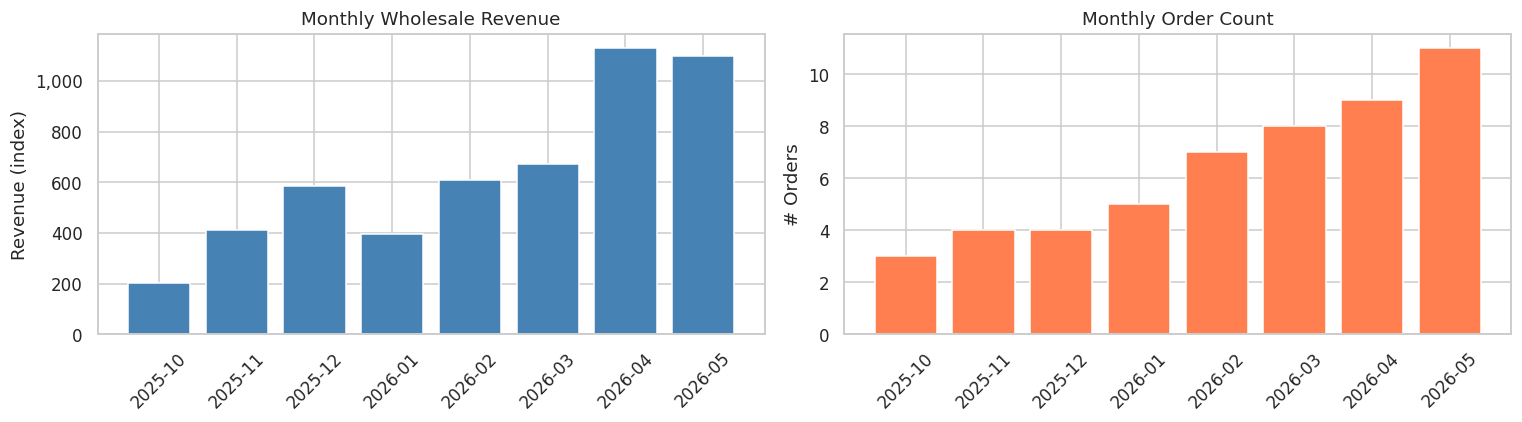

,Order Month,Orders,Wholesale_Rev,Retailers
0,2025-10,3,201.22,3
1,2025-11,4,412.87,3
2,2025-12,4,584.75,4
3,2026-01,5,394.17,4
4,2026-02,7,608.93,6
5,2026-03,8,672.56,8
6,2026-04,9,"1,129.12",8
7,2026-05,11,"1,096.38",9


In [9]:
monthly = order_df.groupby('Order Month').agg(
    Orders       = ('Order Number', 'count'),
    Wholesale_Rev= ('Wholesale_Rev', 'sum'),
    Retailers    = ('Retailer', 'nunique')
).reset_index()
monthly['Order Month'] = monthly['Order Month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(monthly['Order Month'], monthly['Wholesale_Rev'], color='steelblue')
axes[0].set_title('Monthly Wholesale Revenue')
axes[0].set_ylabel('Revenue (index)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(monthly['Order Month'], monthly['Orders'], color='coral')
axes[1].set_title('Monthly Order Count')
axes[1].set_ylabel('# Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
display(monthly)

## 4 · Retailer performance

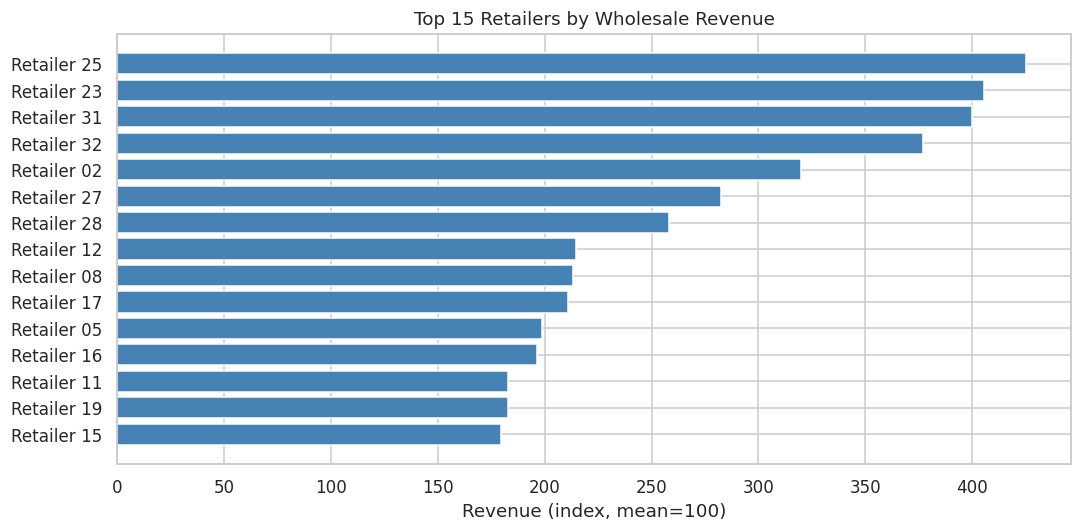

,Retailer,Orders,Total_Units,Wholesale_Rev
0,Retailer 25,4,61,425.06
1,Retailer 23,4,42,405.43
2,Retailer 31,3,37,400.06
3,Retailer 32,3,48,377.13
4,Retailer 02,2,39,319.70
5,Retailer 27,2,29,282.51
6,Retailer 28,2,33,258.14
7,Retailer 12,1,13,214.85
8,Retailer 08,2,35,213.30
9,Retailer 17,3,31,210.93


In [10]:
retailer_df = order_df.groupby('Retailer').agg(
    Orders        = ('Order Number', 'count'),
    Total_Units   = ('Total_Units', 'sum'),
    Wholesale_Rev = ('Wholesale_Rev', 'sum'),
).sort_values('Wholesale_Rev', ascending=False).reset_index()

top_n = 15
top = retailer_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top['Retailer'][::-1], top['Wholesale_Rev'][::-1], color='steelblue')
ax.set_xlabel('Revenue (index, mean=100)')
ax.set_title(f'Top {top_n} Retailers by Wholesale Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

display(retailer_df.head(top_n))

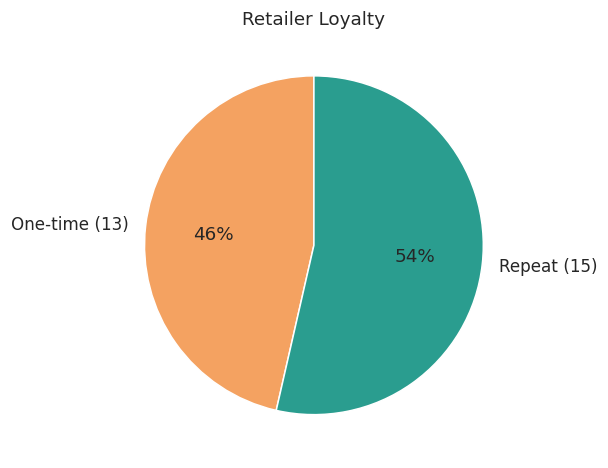


Top repeat buyers:


,Retailer,# Orders
0,Retailer 23,4
1,Retailer 25,4
2,Retailer 15,3
3,Retailer 17,3
4,Retailer 32,3
5,Retailer 31,3
6,Retailer 27,2
7,Retailer 19,2
8,Retailer 16,2
9,Retailer 02,2


In [11]:
order_counts = order_df.groupby('Retailer')['Order Number'].count()
repeat   = (order_counts > 1).sum()
one_time = (order_counts == 1).sum()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([one_time, repeat],
       labels=[f'One-time ({one_time})', f'Repeat ({repeat})'],
       autopct='%1.0f%%', colors=['#f4a261', '#2a9d8f'], startangle=90)
ax.set_title('Retailer Loyalty')
plt.show()

print(f'\nTop repeat buyers:')
display(order_counts.sort_values(ascending=False).head(10).rename('# Orders').reset_index())

## 5 · Geography

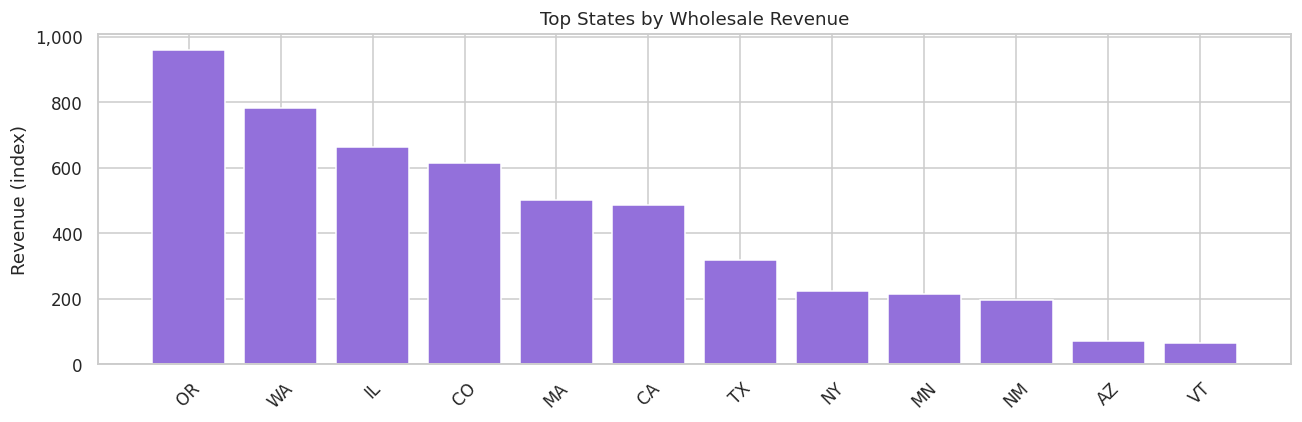


By Country:


,Orders,Wholesale_Rev
Country,,
US,51,"5,100.00"


In [12]:
# By state
state_df = order_df.groupby('State').agg(
    Orders        = ('Order Number', 'count'),
    Wholesale_Rev = ('Wholesale_Rev', 'sum'),
    Retailers     = ('Retailer', 'nunique')
).sort_values('Wholesale_Rev', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(state_df['State'].head(20), state_df['Wholesale_Rev'].head(20), color='mediumpurple')
ax.set_title('Top States by Wholesale Revenue')
ax.set_ylabel('Revenue (index)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\nBy Country:')
display(order_df.groupby('Country').agg(
    Orders=('Order Number','count'),
    Wholesale_Rev=('Wholesale_Rev','sum')
).sort_values('Wholesale_Rev', ascending=False))

## 6 · Product performance

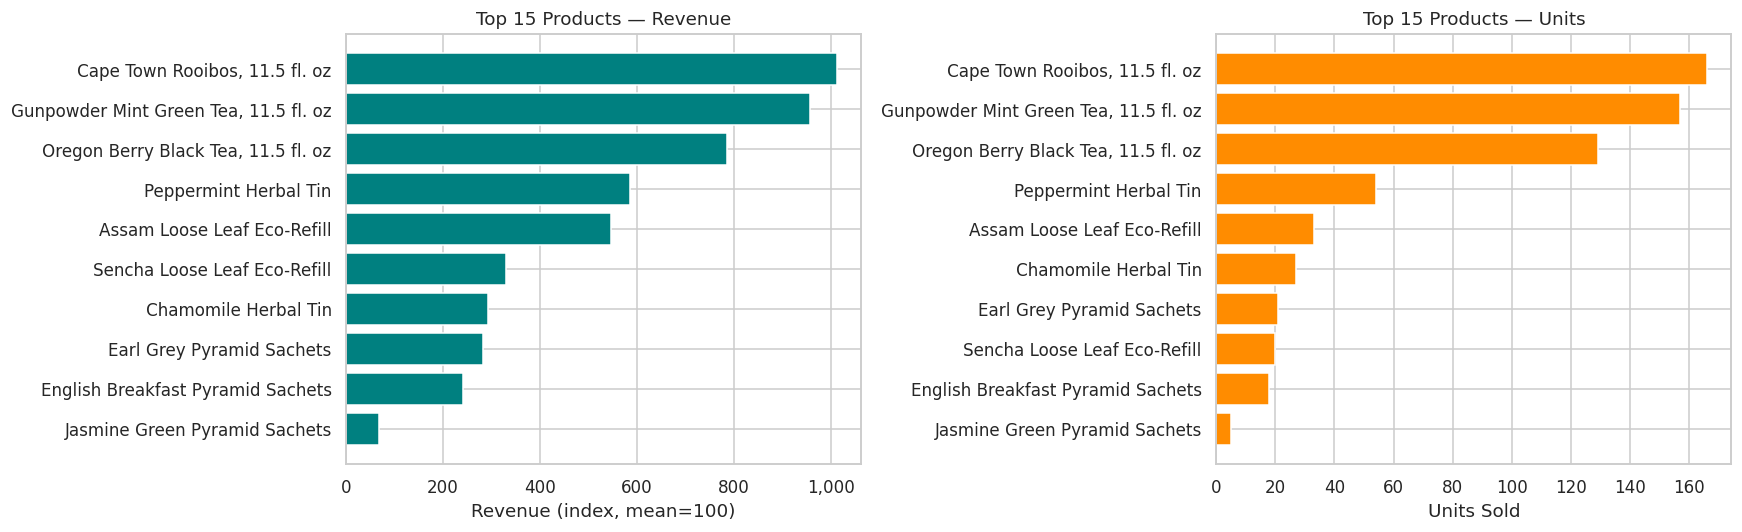

,SKU,Product Name,Units_Sold,Wholesale_Rev,Orders,Avg_Margin_Pct
0,SKU-103,"Cape Town Rooibos, 11.5 fl. oz",166,"1,011.67",32,34.40
1,SKU-102,"Gunpowder Mint Green Tea, 11.5 fl. oz",157,956.82,28,34.40
2,SKU-101,"Oregon Berry Black Tea, 11.5 fl. oz",129,786.18,27,34.40
3,SKU-402,Peppermint Herbal Tin,54,585.68,10,47.50
4,SKU-301,Assam Loose Leaf Eco-Refill,33,545.40,7,46.70
5,SKU-302,Sencha Loose Leaf Eco-Refill,20,330.55,3,46.70
6,SKU-401,Chamomile Herbal Tin,27,292.84,5,47.50
7,SKU-202,Earl Grey Pyramid Sachets,21,282.00,4,45.80
8,SKU-201,English Breakfast Pyramid Sachets,18,241.71,6,45.80
9,SKU-203,Jasmine Green Pyramid Sachets,5,67.14,1,45.80


In [13]:
product_df = df.groupby(['SKU', 'Product Name']).agg(
    Units_Sold      = ('Quantity', 'sum'),
    Wholesale_Rev   = ('Line Wholesale Revenue', 'sum'),
    Orders          = ('Order Number', 'nunique'),
    Avg_Margin_Pct  = ('Margin %', 'mean'),
).sort_values('Wholesale_Rev', ascending=False).reset_index()

top_n = 15
top_prod = product_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Revenue
axes[0].barh(top_prod['Product Name'][::-1], top_prod['Wholesale_Rev'][::-1], color='teal')
axes[0].set_xlabel('Revenue (index, mean=100)')
axes[0].set_title(f'Top {top_n} Products — Revenue')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Units
top_vol = product_df.sort_values('Units_Sold', ascending=False).head(top_n)
axes[1].barh(top_vol['Product Name'][::-1], top_vol['Units_Sold'][::-1], color='darkorange')
axes[1].set_xlabel('Units Sold')
axes[1].set_title(f'Top {top_n} Products — Units')

plt.tight_layout()
plt.show()

display(product_df.head(top_n))

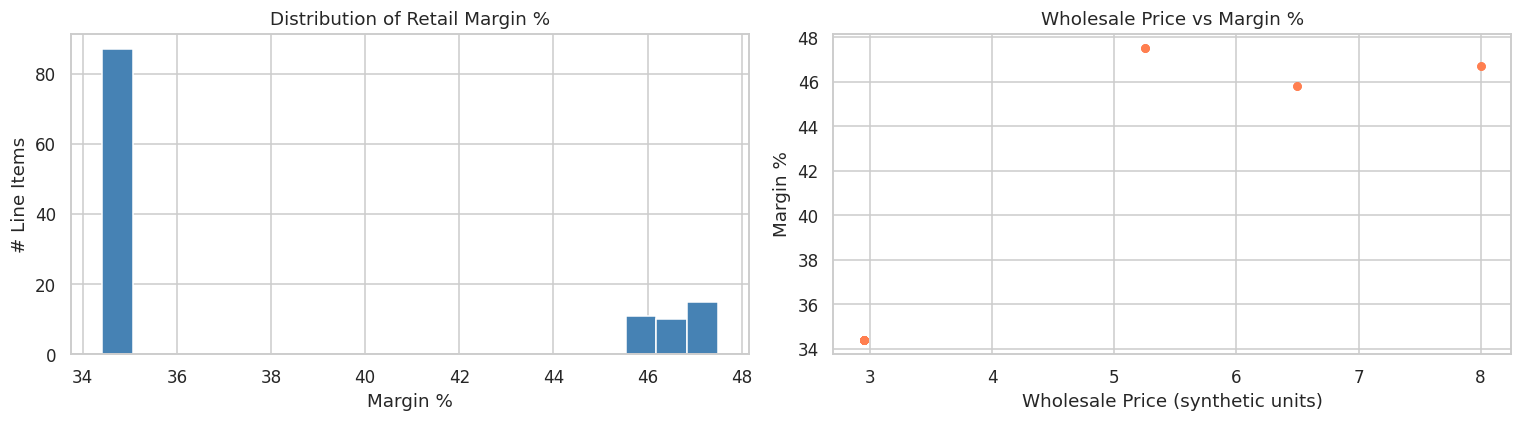


Margin % by Product (top 15 by revenue):


,Product Name,Units_Sold,Orders,Avg_Margin_Pct
0,"Cape Town Rooibos, 11.5 fl. oz",166,32,34.40
1,"Gunpowder Mint Green Tea, 11.5 fl. oz",157,28,34.40
2,"Oregon Berry Black Tea, 11.5 fl. oz",129,27,34.40
3,Peppermint Herbal Tin,54,10,47.50
4,Assam Loose Leaf Eco-Refill,33,7,46.70
5,Sencha Loose Leaf Eco-Refill,20,3,46.70
6,Chamomile Herbal Tin,27,5,47.50
7,Earl Grey Pyramid Sachets,21,4,45.80
8,English Breakfast Pyramid Sachets,18,6,45.80
9,Jasmine Green Pyramid Sachets,5,1,45.80


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of margin %
axes[0].hist(df['Margin %'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Margin %')
axes[0].set_ylabel('# Line Items')
axes[0].set_title('Distribution of Retail Margin %')

# Margin vs wholesale price scatter
axes[1].scatter(df['Wholesale Price'], df['Margin %'], alpha=0.4, color='coral', s=20)
axes[1].set_xlabel('Wholesale Price (synthetic units)')
axes[1].set_ylabel('Margin %')
axes[1].set_title('Wholesale Price vs Margin %')

plt.tight_layout()
plt.show()

print('\nMargin % by Product (top 15 by revenue):')
display(product_df[['Product Name', 'Units_Sold', 'Orders', 'Avg_Margin_Pct']].head(15))

## 7 · Order value & fulfilment speed

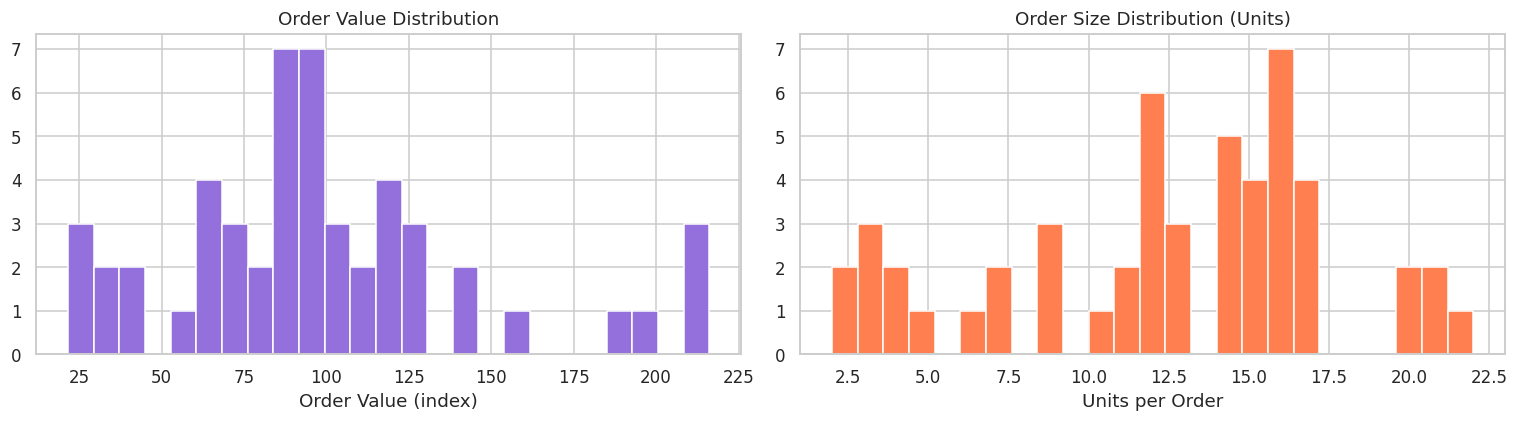


Order value percentiles:


count    51.00
mean    100.00
std      47.51
min      21.69
25%      73.13
50%      97.51
75%     118.79
90%     161.24
95%     205.61
max     216.09
Name: Wholesale_Rev, dtype: float64

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(order_df['Wholesale_Rev'], bins=25, color='mediumpurple', edgecolor='white')
axes[0].set_xlabel('Order Value (index)')
axes[0].set_title('Order Value Distribution')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].hist(order_df['Total_Units'], bins=25, color='coral', edgecolor='white')
axes[1].set_xlabel('Units per Order')
axes[1].set_title('Order Size Distribution (Units)')

plt.tight_layout()
plt.show()

print('\nOrder value percentiles:')
display(order_df['Wholesale_Rev'].describe(percentiles=[.25,.5,.75,.9,.95]))

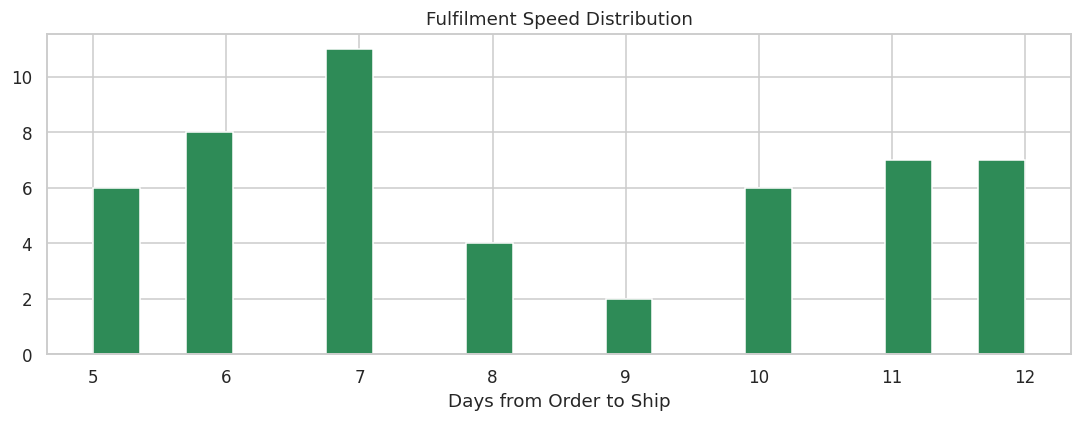

count   51.00
mean     8.35
std      2.42
min      5.00
25%      6.00
50%      8.00
75%     11.00
max     12.00
Name: Days_to_Ship, dtype: float64


In [16]:
ship_df = order_df['Days_to_Ship'].dropna()
ship_df = ship_df[ship_df >= 0]  # remove any data anomalies

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ship_df, bins=20, color='seagreen', edgecolor='white')
ax.set_xlabel('Days from Order to Ship')
ax.set_title('Fulfilment Speed Distribution')
plt.tight_layout()
plt.show()

print(ship_df.describe())

## 8 · New-retailer acquisition

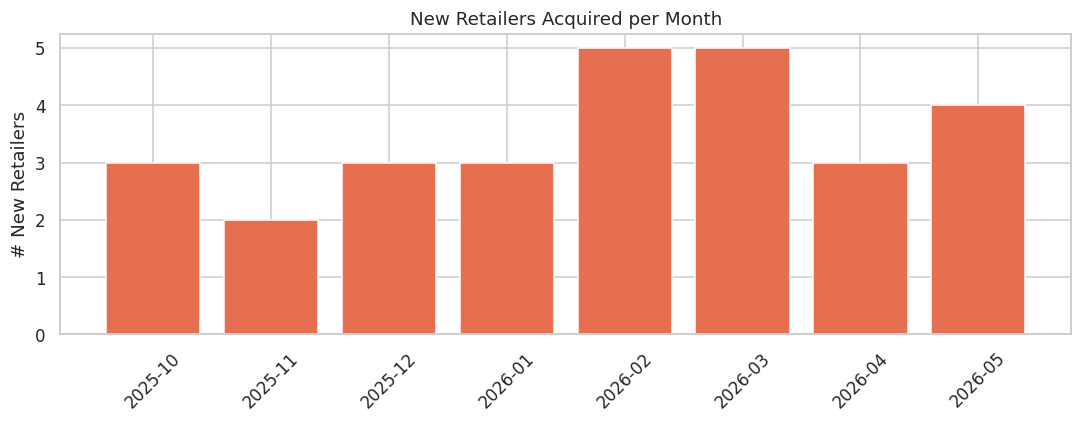

,First Month,New Retailers
0,2025-10,3
1,2025-11,2
2,2025-12,3
3,2026-01,3
4,2026-02,5
5,2026-03,5
6,2026-04,3
7,2026-05,4


In [17]:
first_order = order_df.groupby('Retailer')['Order_Date'].min().reset_index()
first_order['First Month'] = first_order['Order_Date'].dt.to_period('M').astype(str)
new_per_month = first_order.groupby('First Month').size().reset_index(name='New Retailers')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(new_per_month['First Month'], new_per_month['New Retailers'], color='#e76f51')
ax.set_title('New Retailers Acquired per Month')
ax.set_ylabel('# New Retailers')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

display(new_per_month)

## 9 · Revenue concentration (Pareto / 80-20)
How dependent is the channel on its top retailers?

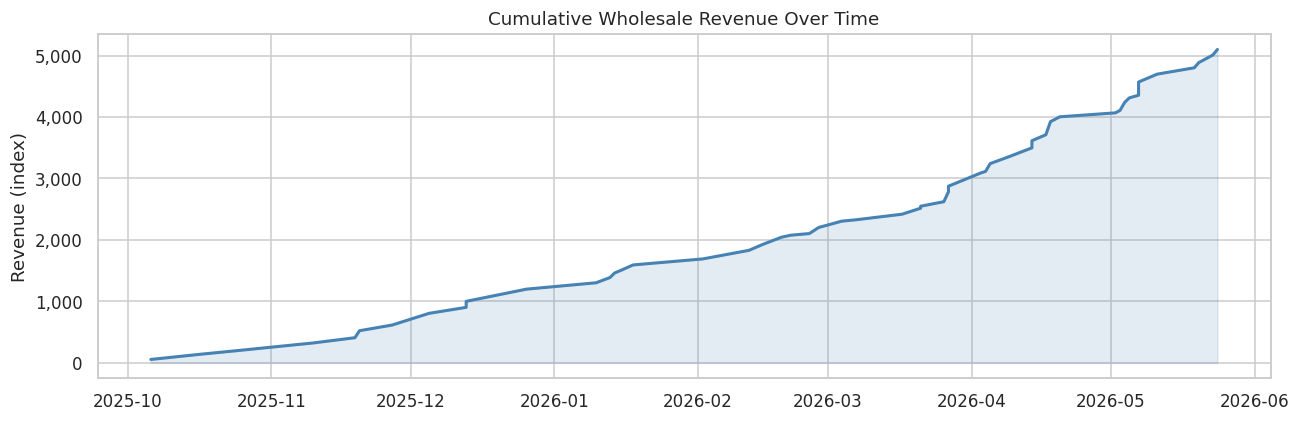

In [18]:
monthly_sorted = order_df.sort_values('Order_Date').copy()
monthly_sorted['Cumulative Revenue'] = monthly_sorted['Wholesale_Rev'].cumsum()
monthly_sorted['Order #'] = range(1, len(monthly_sorted) + 1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_sorted['Order_Date'], monthly_sorted['Cumulative Revenue'], color='steelblue', linewidth=2)
ax.fill_between(monthly_sorted['Order_Date'], monthly_sorted['Cumulative Revenue'], alpha=0.15, color='steelblue')
ax.set_title('Cumulative Wholesale Revenue Over Time')
ax.set_ylabel('Revenue (index)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

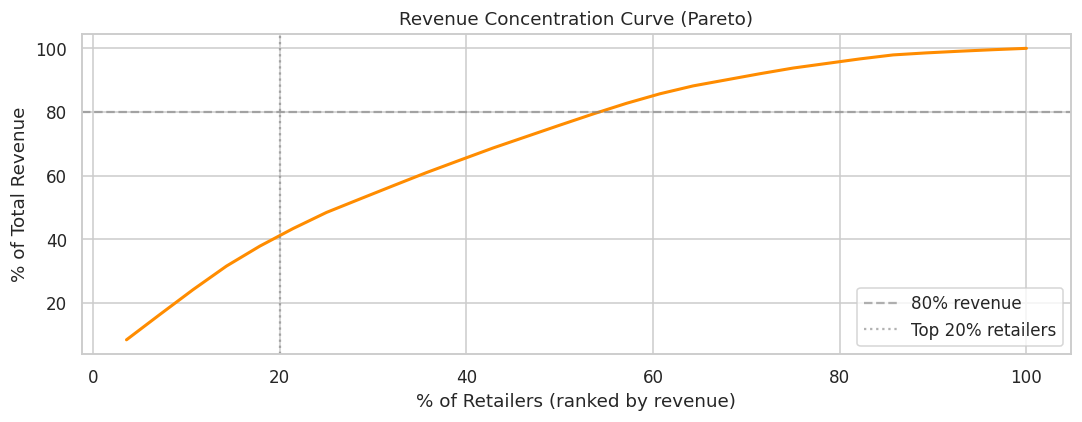

Top 15 retailers (54%) drive 80% of revenue


In [19]:
retailer_sorted = retailer_df.sort_values('Wholesale_Rev', ascending=False).copy()
retailer_sorted['Cumulative Rev'] = retailer_sorted['Wholesale_Rev'].cumsum()
retailer_sorted['Cumulative Rev %'] = retailer_sorted['Cumulative Rev'] / retailer_sorted['Wholesale_Rev'].sum() * 100
retailer_sorted['Retailer Rank'] = range(1, len(retailer_sorted) + 1)
retailer_sorted['Retailer %'] = retailer_sorted['Retailer Rank'] / len(retailer_sorted) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(retailer_sorted['Retailer %'], retailer_sorted['Cumulative Rev %'], color='darkorange', linewidth=2)
ax.axhline(80, color='gray', linestyle='--', alpha=0.6, label='80% revenue')
ax.axvline(20, color='gray', linestyle=':',  alpha=0.6, label='Top 20% retailers')
ax.set_xlabel('% of Retailers (ranked by revenue)')
ax.set_ylabel('% of Total Revenue')
ax.set_title('Revenue Concentration Curve (Pareto)')
ax.legend()
plt.tight_layout()
plt.show()

# Where does 80% of revenue come from?
threshold = retailer_sorted[retailer_sorted['Cumulative Rev %'] <= 80]
print(f"Top {len(threshold)} retailers ({len(threshold)/len(retailer_sorted)*100:.0f}%) drive 80% of revenue")

## 10 · Day-of-week ordering pattern

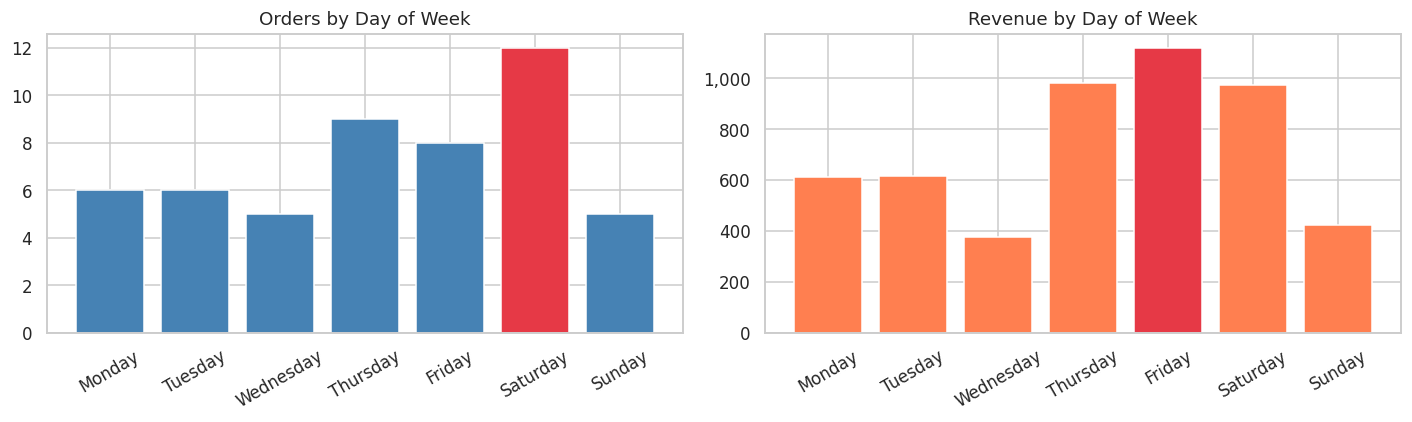

=== Day of Week Highlights ===



📦 Orders
   Best day : Saturday — 12 orders (23.5% of all orders)
   All days : 51 orders total

💰 Revenue
   Best day : Friday — 1,119 idx (21.9% of all revenue)
   All days : 5,100 idx total


In [20]:
order_df['Day of Week'] = order_df['Order_Date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_df = order_df.groupby('Day of Week').agg(
    Orders=('Order Number','count'),
    Revenue=('Wholesale_Rev','sum')
).reindex(dow_order)

# --- highlight colours: top day vs rest ---
top_orders_day  = dow_df['Orders'].idxmax()
top_revenue_day = dow_df['Revenue'].idxmax()

order_colors  = ['#e63946' if d == top_orders_day  else 'steelblue' for d in dow_df.index]
revenue_colors = ['#e63946' if d == top_revenue_day else 'coral'     for d in dow_df.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(dow_df.index, dow_df['Orders'], color=order_colors)
axes[0].set_title('Orders by Day of Week')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dow_df.index, dow_df['Revenue'], color=revenue_colors)
axes[1].set_title('Revenue by Day of Week')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# --- printed summary ---
total_orders  = dow_df['Orders'].sum()
total_revenue = dow_df['Revenue'].sum()

top_ord_count = dow_df.loc[top_orders_day,  'Orders']
top_rev_amt   = dow_df.loc[top_revenue_day, 'Revenue']

print("=== Day of Week Highlights ===")
print(f"\n📦 Orders")
print(f"   Best day : {top_orders_day} — {top_ord_count} orders ({top_ord_count/total_orders*100:.1f}% of all orders)")
print(f"   All days : {total_orders} orders total")

print(f"\n💰 Revenue")
print(f"   Best day : {top_revenue_day} — {top_rev_amt:,.0f} idx ({top_rev_amt/total_revenue*100:.1f}% of all revenue)")
print(f"   All days : {total_revenue:,.0f} idx total")

## 11 · Average order value over time

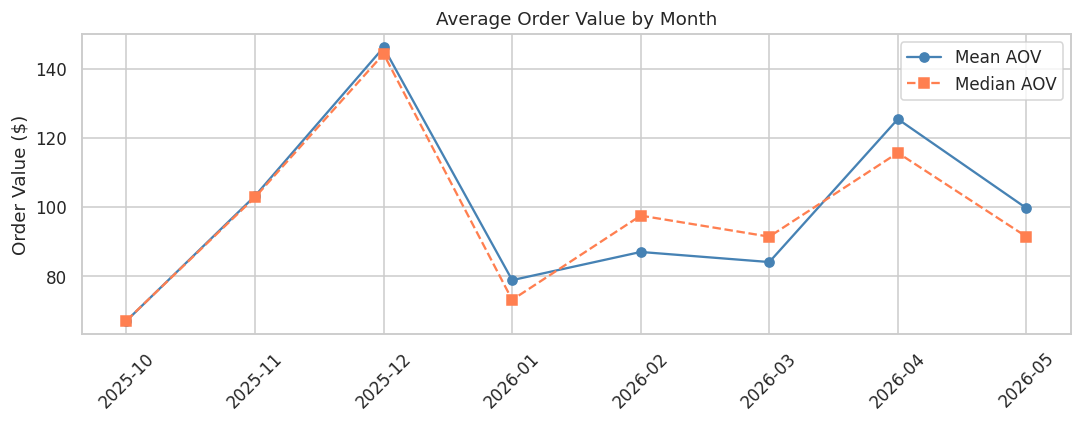

In [21]:
aov_monthly = order_df.groupby('Order Month').agg(
    AOV=('Wholesale_Rev', 'mean'),
    Median_Order=('Wholesale_Rev', 'median')
).reset_index()
aov_monthly['Order Month'] = aov_monthly['Order Month'].astype(str)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(aov_monthly['Order Month'], aov_monthly['AOV'],    marker='o', label='Mean AOV', color='steelblue')
ax.plot(aov_monthly['Order Month'], aov_monthly['Median_Order'], marker='s', label='Median AOV', color='coral', linestyle='--')
ax.set_title('Average Order Value by Month')
ax.set_ylabel('Order Value ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 12 · Revenue choropleth
Interactive US map of wholesale revenue by state (requires `plotly`).

In [22]:
# Requires: pip install plotly
import plotly.express as px

state_map = order_df.groupby('State').agg(
    Orders=('Order Number','count'),
    Revenue=('Wholesale_Rev','sum'),
    Retailers=('Retailer','nunique')
).reset_index()

fig = px.choropleth(
    state_map,
    locations='State',
    locationmode='USA-states',
    color='Revenue',
    scope='usa',
    color_continuous_scale='Blues',
    hover_data=['Orders', 'Retailers'],
    title='Wholesale Revenue by State'
)
fig.show()

## 13 · Basket / co-occurrence analysis  ⭐

The headline insight: which products get ordered **together**. This surfaced a trio of canned flavors co-occurring in a large share of orders — the evidence behind a bundle strategy.

In [23]:
from itertools import combinations
from collections import Counter

# Get all SKUs per order
baskets = df.groupby('Order Number')['Product Name'].apply(list)

# Count co-occurrences
pair_counts = Counter()
for items in baskets:
    unique_items = list(set(items))
    for pair in combinations(sorted(unique_items), 2):
        pair_counts[pair] += 1

pairs_df = pd.DataFrame(pair_counts.most_common(20),
                        columns=['Product Pair', 'Co-occurrence Count'])
pairs_df[['Product A', 'Product B']] = pd.DataFrame(pairs_df['Product Pair'].tolist())
pairs_df = pairs_df.drop('Product Pair', axis=1)[['Product A', 'Product B', 'Co-occurrence Count']]

print('Top 20 most frequently co-ordered product pairs:')
display(pairs_df)

Top 20 most frequently co-ordered product pairs:


,Product A,Product B,Co-occurrence Count
0,"Cape Town Rooibos, 11.5 fl. oz","Oregon Berry Black Tea, 11.5 fl. oz",26
1,"Cape Town Rooibos, 11.5 fl. oz","Gunpowder Mint Green Tea, 11.5 fl. oz",25
2,"Gunpowder Mint Green Tea, 11.5 fl. oz","Oregon Berry Black Tea, 11.5 fl. oz",25
3,"Cape Town Rooibos, 11.5 fl. oz",Peppermint Herbal Tin,3
4,Assam Loose Leaf Eco-Refill,Earl Grey Pyramid Sachets,2
5,"Cape Town Rooibos, 11.5 fl. oz",English Breakfast Pyramid Sachets,2
6,English Breakfast Pyramid Sachets,Peppermint Herbal Tin,2
7,Assam Loose Leaf Eco-Refill,"Cape Town Rooibos, 11.5 fl. oz",2
8,Chamomile Herbal Tin,"Gunpowder Mint Green Tea, 11.5 fl. oz",2
9,Assam Loose Leaf Eco-Refill,"Gunpowder Mint Green Tea, 11.5 fl. oz",1


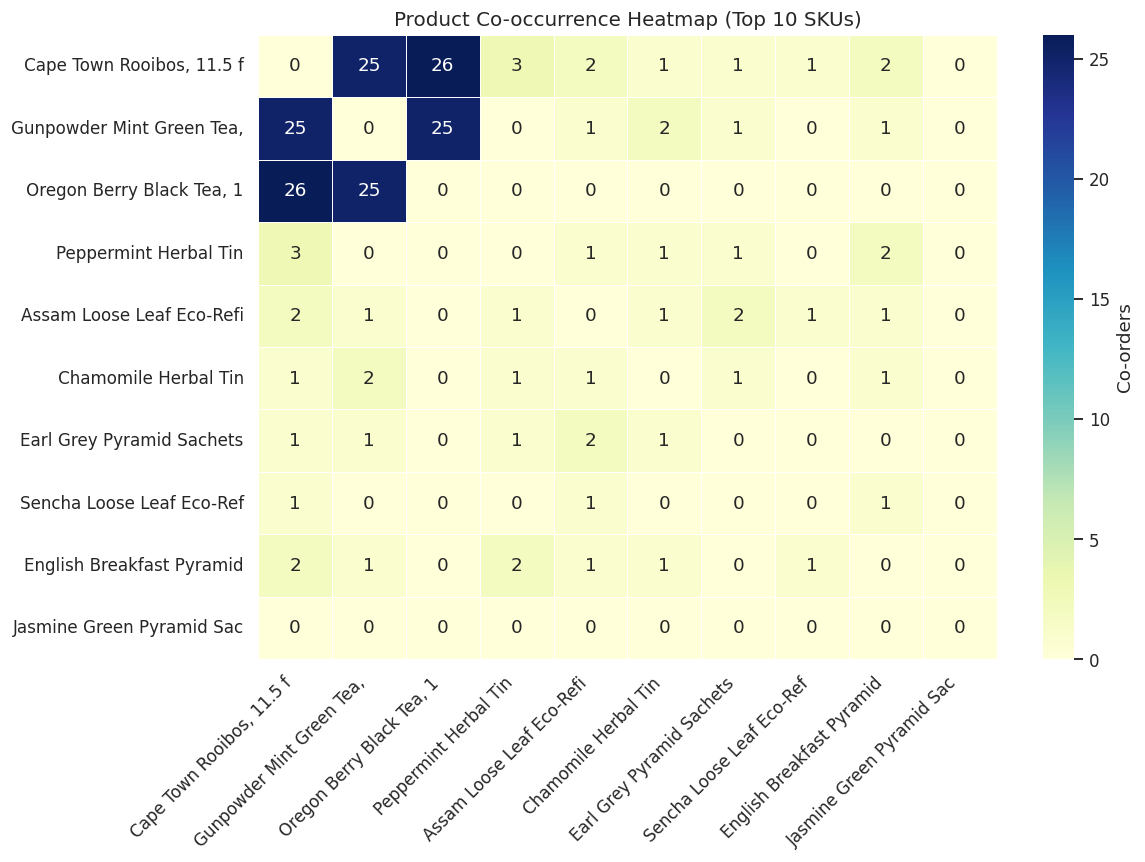

In [24]:
# Co-occurrence heatmap for top N products
top_products = df.groupby('Product Name')['Quantity'].sum().nlargest(10).index.tolist()

# Build matrix
matrix = pd.DataFrame(0, index=top_products, columns=top_products)
for items in baskets:
    items_filtered = [i for i in set(items) if i in top_products]
    for a, b in combinations(sorted(items_filtered), 2):
        matrix.loc[a, b] += 1
        matrix.loc[b, a] += 1

# Shorten labels for readability
short_labels = [p.split('–')[0].strip()[:25] for p in top_products]
matrix.index = short_labels
matrix.columns = short_labels

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlGnBu',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Co-orders'})
ax.set_title('Product Co-occurrence Heatmap (Top 10 SKUs)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 14 · RFM retailer segmentation  ⭐

Score every retailer on **R**ecency, **F**requency, **M**onetary value, then bucket into *At Risk · Promising · Top Retailer* to prioritize outreach.

In [25]:
# Score each retailer on recency, frequency, value (RFM-lite)
import datetime

snapshot = df['Order Date'].max() if 'Order Date' in df.columns else snapshot
df['Order Date'] = pd.to_datetime(df['Order Date'])

rfm = df.groupby('Retailer Name').agg(
    Last_Order  = ('Order Date', 'max'),
    Orders      = ('Order Number', 'nunique'),
    Revenue     = ('Line Wholesale Revenue', 'sum')
).reset_index()

rfm['Days Since Order'] = (snapshot - rfm['Last_Order']).dt.days

# Score 1-3 each dimension
rfm['R'] = pd.qcut(rfm['Days Since Order'], q=3, labels=[3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['Orders'].rank(method='first'), q=3, labels=[1,2,3]).astype(int)
rfm['M'] = pd.qcut(rfm['Revenue'].rank(method='first'), q=3, labels=[1,2,3]).astype(int)
rfm['RFM Score'] = rfm['R'] + rfm['F'] + rfm['M']

rfm['Segment'] = pd.cut(rfm['RFM Score'], bins=[2,4,6,9],
                         labels=['At Risk', 'Promising', 'Top Retailer'])

rfm = rfm.sort_values('RFM Score', ascending=False)
print("Retailer Segments:")
display(rfm[['Retailer Name','Days Since Order','Orders','Revenue','RFM Score','Segment']])

print("\nSegment summary:")
display(rfm.groupby('Segment').agg(Count=('Retailer Name','count'), Avg_Revenue=('Revenue','mean')).round(2))

Retailer Segments:


,Retailer Name,Days Since Order,Orders,Revenue,RFM Score,Segment
22,Retailer 28,13,2,258.14,9,Top Retailer
17,Retailer 23,34,4,405.43,9,Top Retailer
11,Retailer 15,5,3,179.53,8,Top Retailer
6,Retailer 08,1,2,213.30,8,Top Retailer
13,Retailer 17,21,3,210.93,8,Top Retailer
21,Retailer 27,0,2,282.51,8,Top Retailer
26,Retailer 32,36,3,377.13,8,Top Retailer
25,Retailer 31,58,3,400.06,8,Top Retailer
12,Retailer 16,4,2,196.47,7,Top Retailer
19,Retailer 25,131,4,425.06,7,Top Retailer



Segment summary:


,Count,Avg_Revenue
Segment,,
At Risk,8,71.53
Promising,7,124.85
Top Retailer,13,281.06


## 15 · Overdue-reorder flagging
Learn each repeat retailer's own reorder cadence, then flag who's past due against their personal pattern.

In [26]:
# For retailers with 2+ orders, what is their avg reorder cycle?
# Flag anyone who is past due

order_dates = df.groupby(['Retailer Name','Order Number'])['Order Date'].min().reset_index()
order_dates = order_dates.sort_values(['Retailer Name','Order Date'])
order_dates['Prev Order'] = order_dates.groupby('Retailer Name')['Order Date'].shift(1)
order_dates['Gap Days'] = (order_dates['Order Date'] - order_dates['Prev Order']).dt.days

avg_cycle = order_dates.dropna().groupby('Retailer Name')['Gap Days'].mean().reset_index()
avg_cycle.columns = ['Retailer Name', 'Avg Reorder Days']

last_order = order_dates.groupby('Retailer Name')['Order Date'].max().reset_index()
last_order.columns = ['Retailer Name', 'Last Order']
last_order['Days Since'] = (pd.Timestamp('2026-05-12') - last_order['Last Order']).dt.days

overdue = last_order.merge(avg_cycle, on='Retailer Name')
overdue['Days Overdue'] = overdue['Days Since'] - overdue['Avg Reorder Days']
overdue = overdue[overdue['Days Overdue'] > 0].sort_values('Days Overdue', ascending=False)

print("Retailers likely overdue for reorder:")
display(overdue)

Retailers likely overdue for reorder:


,Retailer Name,Last Order,Days Since,Avg Reorder Days,Days Overdue
8,Retailer 25,2026-01-13,119,21.33,97.67
11,Retailer 29,2025-12-13,150,68.00,82.00
13,Retailer 31,2026-03-27,46,21.50,24.50
0,Retailer 02,2026-04-03,39,30.00,9.00


## 16 · Solo-rate (upsell opportunities)
How often is each SKU the *only* item in an order? High solo-rate = upsell candidate.

In [27]:
# Solo rate: how often is a SKU the ONLY product in an order?
order_sku_count = df.groupby('Order Number')['Product Name'].nunique()
solo_orders = order_sku_count[order_sku_count == 1].index

solo_skus = df[df['Order Number'].isin(solo_orders)].groupby('Product Name')['Order Number'].nunique()
total_skus = df.groupby('Product Name')['Order Number'].nunique()

sku_solo = pd.DataFrame({'Total Orders': total_skus, 'Solo Orders': solo_skus}).fillna(0)
sku_solo['Solo Rate %'] = (sku_solo['Solo Orders'] / sku_solo['Total Orders'] * 100).round(1)
sku_solo = sku_solo.sort_values('Solo Rate %', ascending=False)

print("SKU solo vs bundle rate:")
display(sku_solo)

SKU solo vs bundle rate:


,Total Orders,Solo Orders,Solo Rate %
Product Name,,,
Jasmine Green Pyramid Sachets,1,1.00,100.00
Peppermint Herbal Tin,10,5.00,50.00
English Breakfast Pyramid Sachets,6,2.00,33.30
Sencha Loose Leaf Eco-Refill,3,1.00,33.30
Assam Loose Leaf Eco-Refill,7,1.00,14.30
"Oregon Berry Black Tea, 11.5 fl. oz",27,1.00,3.70
"Cape Town Rooibos, 11.5 fl. oz",32,0.00,0.00
"Gunpowder Mint Green Tea, 11.5 fl. oz",28,0.00,0.00
Chamomile Herbal Tin,5,0.00,0.00


## 17 · Reorder revenue scenario model
Simple what-if: revenue upside if a share of one-time retailers reorder once.

In [28]:
# What-if: if X% of one-time retailers reorder once at the average order value
avg_order_val   = order_df['Wholesale_Rev'].mean()
one_time_count  = (order_df.groupby('Retailer')['Order Number'].count() == 1).sum()
current_total   = order_df['Wholesale_Rev'].sum()

print("=== Reorder Revenue Scenarios ===\n")
for pct in [25, 40, 50, 75, 100]:
    converters = round(one_time_count * pct / 100)
    extra_rev  = converters * avg_order_val
    print(f"  {pct}% convert ({converters} retailers) -> +{extra_rev:,.0f} idx -> Total: {current_total + extra_rev:,.0f} idx")

=== Reorder Revenue Scenarios ===

  25% convert (3 retailers) -> +300 idx -> Total: 5,400 idx
  40% convert (5 retailers) -> +500 idx -> Total: 5,600 idx
  50% convert (6 retailers) -> +600 idx -> Total: 5,700 idx
  75% convert (10 retailers) -> +1,000 idx -> Total: 6,100 idx
  100% convert (13 retailers) -> +1,300 idx -> Total: 6,400 idx


## 18 · Seasonal index
Index each month against the average (100 = average month) to spot over/under-performers.

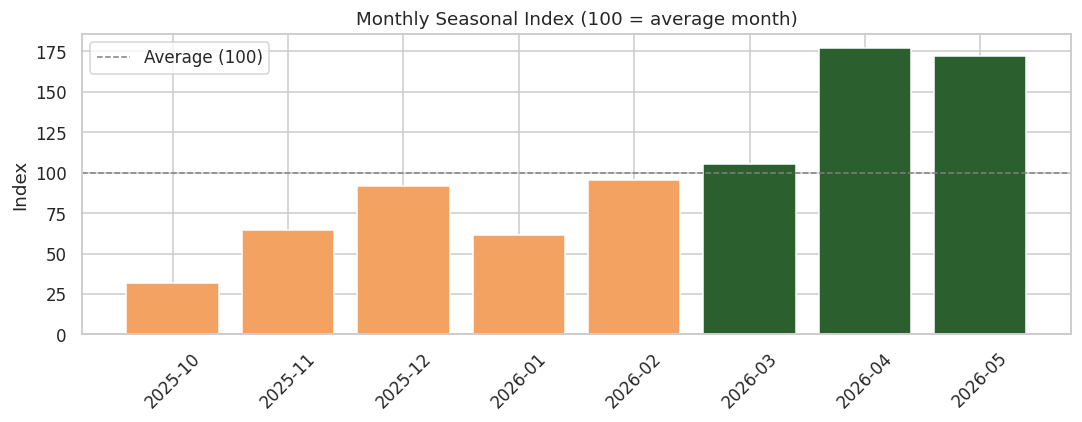

Month
2025-10    31.60
2025-11    64.80
2025-12    91.70
2026-01    61.80
2026-02    95.50
2026-03   105.50
2026-04   177.10
2026-05   172.00
Freq: M, Name: Line Wholesale Revenue, dtype: float64


In [29]:
monthly_rev = df.copy()
monthly_rev['Order Date'] = pd.to_datetime(monthly_rev['Order Date'])
monthly_rev['Month'] = monthly_rev['Order Date'].dt.to_period('M')
monthly_totals = monthly_rev.groupby('Month')['Line Wholesale Revenue'].sum()

avg = monthly_totals.mean()
seasonal_index = (monthly_totals / avg * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2C5F2E' if v >= 100 else '#f4a261' for v in seasonal_index.values]
ax.bar(seasonal_index.index.astype(str), seasonal_index.values, color=colors)
ax.axhline(100, color='gray', linestyle='--', linewidth=1, label='Average (100)')
ax.set_title('Monthly Seasonal Index (100 = average month)')
ax.set_ylabel('Index')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print(seasonal_index)

## 19 · Retailer-type segmentation  ⭐

Classify each retailer by type (Co-op, Cafe, Bottle Shop, …) and analyze revenue, AOV, what each type buys, and repeat rate by type.

In [30]:
# Classify retailer by type. (On real data this used keyword matching on retailer names;
# here we surface the generated type for a clean, reproducible portfolio run.)
df = df.merge(ret_df[['Retailer Name','Retailer Type_true']], on='Retailer Name', how='left')
df['Retailer Type'] = df['Retailer Type_true']
df.drop(columns=['Retailer Type_true'], inplace=True)

# Ensure price columns are numeric
for col in ['Wholesale Price','Retail Price']:
    if df[col].dtype == object:
        df[col] = df[col].str.replace('$','',regex=False).str.replace(',','',regex=False).astype(float)
df['Order Date'] = pd.to_datetime(df['Order Date'])
if 'Line Wholesale Revenue' not in df.columns:
    df['Line Wholesale Revenue'] = df['Quantity'] * df['Wholesale Price']
print(df['Retailer Type'].value_counts())

Retailer Type
Farm Store                28
Cafe & Bakery             24
Gift & Boutique           23
Co-op & Natural Grocer    19
Specialty Grocery         14
Bottle Shop               13
Hospitality                2
Name: count, dtype: int64


In [31]:
# ── Step 2: Revenue & order metrics by retailer type ──────────────────────

type_orders = df.groupby(['Order Number','Retailer Type']).agg(
    Retailer      = ('Retailer Name','first'),
    Order_Date    = ('Order Date','min'),
    Total_Units   = ('Quantity','sum'),
    Wholesale_Rev = ('Line Wholesale Revenue','sum'),
    Unique_SKUs   = ('SKU','nunique'),
).reset_index()

type_summary = type_orders.groupby('Retailer Type').agg(
    Orders        = ('Order Number','count'),
    Retailers     = ('Retailer','nunique'),
    Total_Units   = ('Total_Units','sum'),
    Total_Rev     = ('Wholesale_Rev','sum'),
    Avg_AOV       = ('Wholesale_Rev','mean'),
    Avg_SKUs      = ('Unique_SKUs','mean'),
).round(2).sort_values('Total_Rev', ascending=False).reset_index()

type_summary['Rev Share %'] = (type_summary['Total_Rev'] / type_summary['Total_Rev'].sum() * 100).round(1)
type_summary['Avg Orders per Retailer'] = (type_summary['Orders'] / type_summary['Retailers']).round(1)

print("Performance by Retailer Type:")
display(type_summary)

Performance by Retailer Type:


,Retailer Type,Orders,Retailers,Total_Units,Total_Rev,Avg_AOV,Avg_SKUs,Rev Share %,Avg Orders per Retailer
0,Gift & Boutique,10,5,121,"1,161.56",116.16,2.30,22.80,2.00
1,Farm Store,10,4,150,"1,062.50",106.25,2.80,20.80,2.50
2,Cafe & Bakery,9,5,127,872.85,96.98,2.67,17.10,1.80
3,Co-op & Natural Grocer,10,6,92,817.69,81.77,1.90,16.00,1.70
4,Bottle Shop,5,3,65,570.71,114.14,2.60,11.20,1.70
5,Specialty Grocery,6,4,62,399.86,66.64,2.33,7.80,1.50
6,Hospitality,1,1,13,214.85,214.85,2.00,4.20,1.00


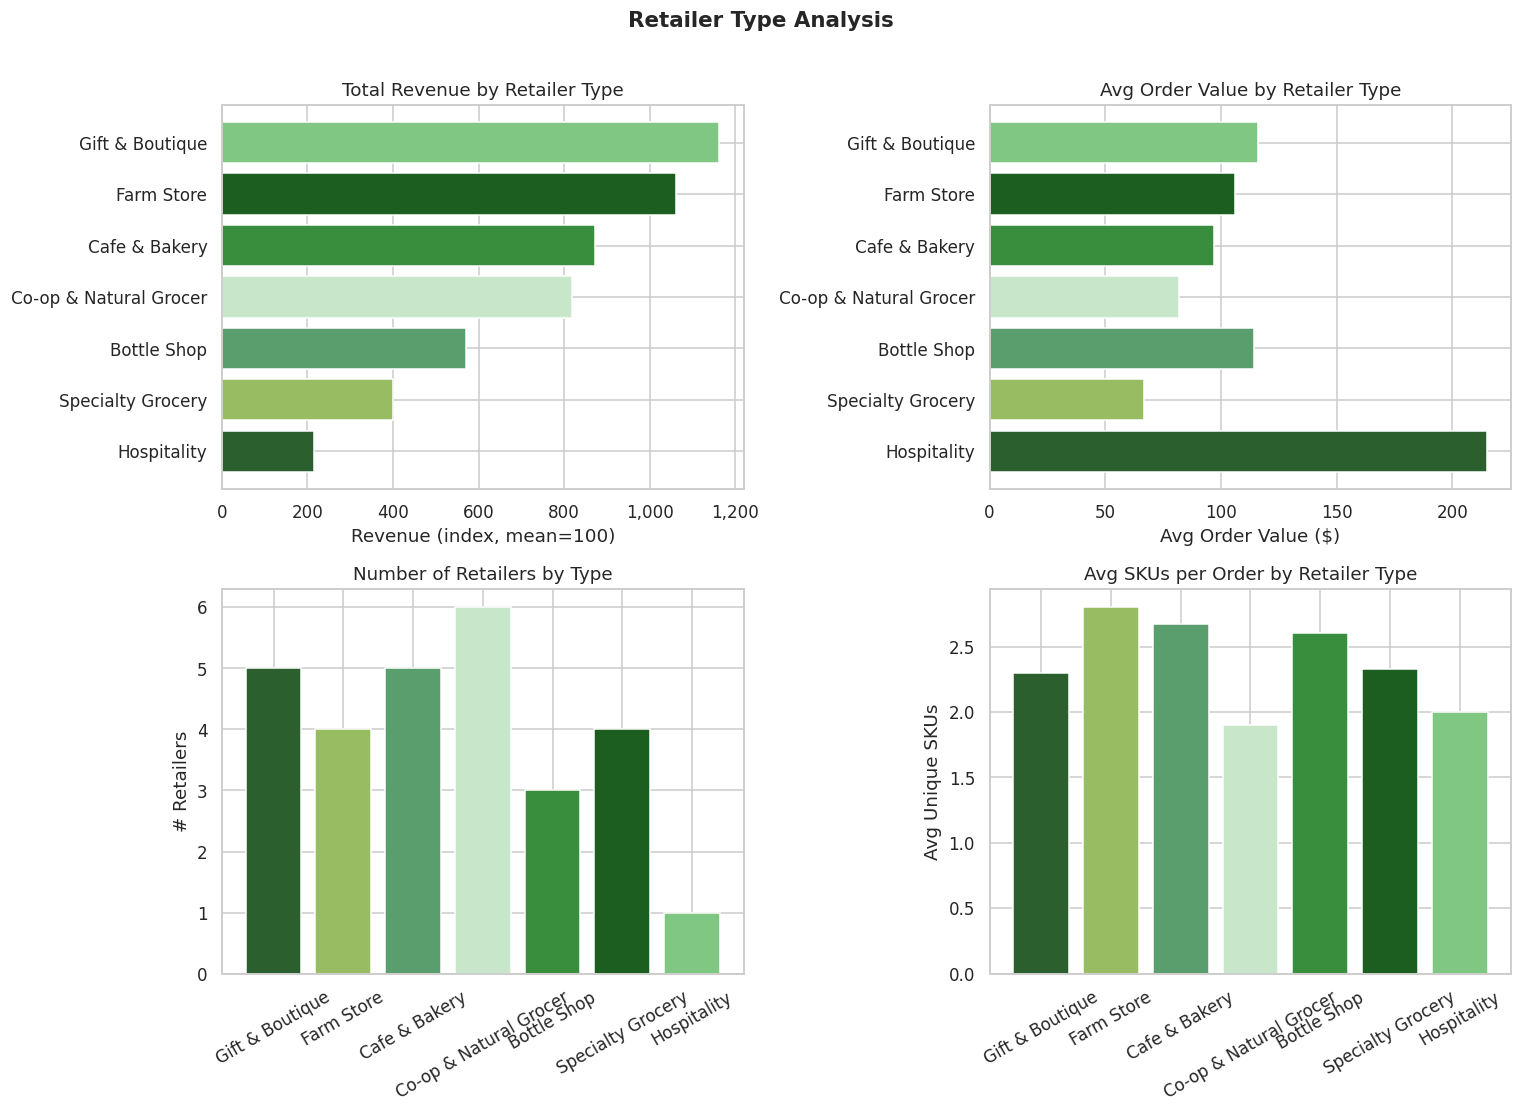

In [32]:
# ── Step 3: Visualise ──────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#2C5F2E','#97BC62','#5a9e6e','#c8e6c9','#388e3c','#1b5e20','#81c784']

# Revenue by type
axes[0,0].barh(type_summary['Retailer Type'][::-1], type_summary['Total_Rev'][::-1], color=colors[:len(type_summary)])
axes[0,0].set_title('Total Revenue by Retailer Type')
axes[0,0].set_xlabel('Revenue (index, mean=100)')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# Avg order value by type
axes[0,1].barh(type_summary['Retailer Type'][::-1], type_summary['Avg_AOV'][::-1], color=colors[:len(type_summary)])
axes[0,1].set_title('Avg Order Value by Retailer Type')
axes[0,1].set_xlabel('Avg Order Value ($)')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# Retailer count by type
axes[1,0].bar(type_summary['Retailer Type'], type_summary['Retailers'], color=colors[:len(type_summary)])
axes[1,0].set_title('Number of Retailers by Type')
axes[1,0].set_ylabel('# Retailers')
axes[1,0].tick_params(axis='x', rotation=30)

# Avg SKUs per order by type
axes[1,1].bar(type_summary['Retailer Type'], type_summary['Avg_SKUs'], color=colors[:len(type_summary)])
axes[1,1].set_title('Avg SKUs per Order by Retailer Type')
axes[1,1].set_ylabel('Avg Unique SKUs')
axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle('Retailer Type Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [33]:
# ── Step 4: What does each retailer type actually buy? ────────────────────

type_product = df.groupby(['Retailer Type','Product Name']).agg(
    Units   = ('Quantity','sum'),
    Revenue = ('Line Wholesale Revenue','sum'),
    Orders  = ('Order Number','nunique'),
).reset_index().sort_values(['Retailer Type','Revenue'], ascending=[True,False])

# Top 3 products per retailer type
print("Top products per retailer type:\n")
for rtype in type_summary['Retailer Type']:
    subset = type_product[type_product['Retailer Type'] == rtype].head(3)
    print(f"  {rtype}")
    for _, row in subset.iterrows():
        print(f"    {row['Product Name'][:50]:<52}  {int(row['Units'])} units   ({row['Revenue']:,.0f} rev idx)")
    print()

Top products per retailer type:

  Gift & Boutique
    Peppermint Herbal Tin                                 20 units   (217 rev idx)
    Gunpowder Mint Green Tea, 11.5 fl. oz                 27 units   (165 rev idx)
    English Breakfast Pyramid Sachets                     12 units   (161 rev idx)

  Farm Store
    Cape Town Rooibos, 11.5 fl. oz                        44 units   (268 rev idx)
    Oregon Berry Black Tea, 11.5 fl. oz                   42 units   (256 rev idx)
    Gunpowder Mint Green Tea, 11.5 fl. oz                 38 units   (232 rev idx)

  Cafe & Bakery
    Cape Town Rooibos, 11.5 fl. oz                        43 units   (262 rev idx)
    Gunpowder Mint Green Tea, 11.5 fl. oz                 37 units   (225 rev idx)
    Oregon Berry Black Tea, 11.5 fl. oz                   30 units   (183 rev idx)

  Co-op & Natural Grocer
    Cape Town Rooibos, 11.5 fl. oz                        25 units   (152 rev idx)
    Gunpowder Mint Green Tea, 11.5 fl. oz                 24 u

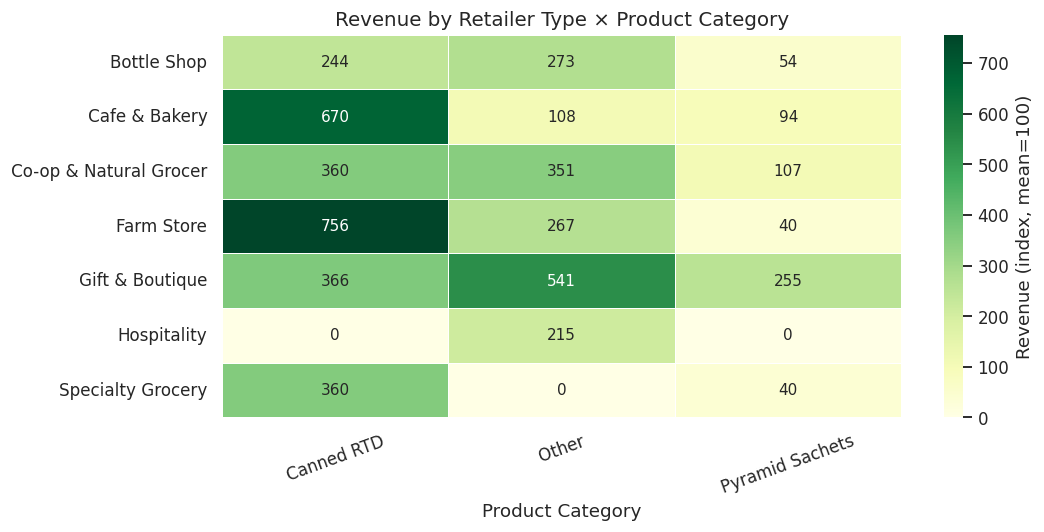

In [34]:
# ── Step 5: Heatmap — retailer type vs product category ───────────────────

# Simplify product names to format categories
def product_category(name):
    if '11.5 fl. oz' in name:
        return 'Canned RTD'
    if 'Pyramid' in name:
        return 'Pyramid Sachets'
    if 'Eco Collection' in name or 'Tea Bags' in name:
        return 'Eco Tea Bags'
    return 'Other'

df['Product Category'] = df['Product Name'].apply(product_category)

pivot = df.groupby(['Retailer Type','Product Category'])['Line Wholesale Revenue'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGn',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Revenue (index, mean=100)'},
            annot_kws={'size': 10})
ax.set_title('Revenue by Retailer Type × Product Category', fontsize=13)
ax.set_xlabel('Product Category')
ax.set_ylabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

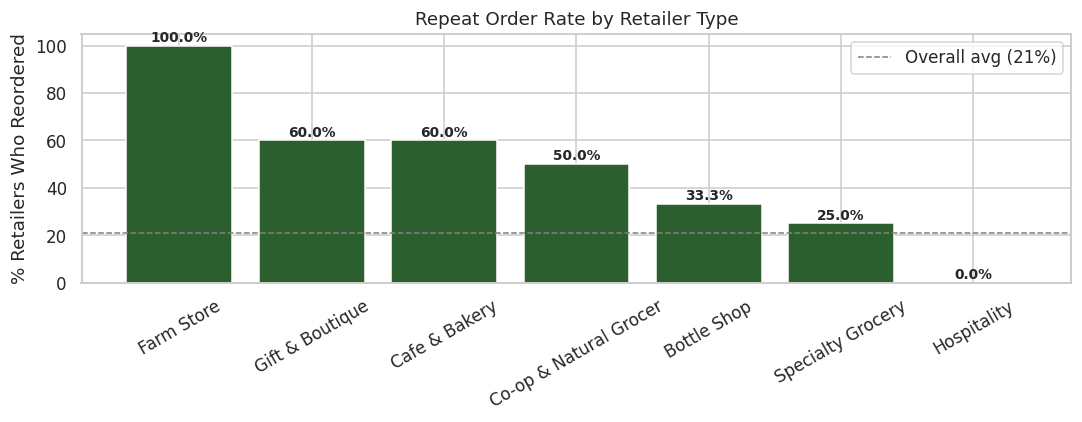

,Retailer Type,Total,Repeats,Repeat Rate %
3,Farm Store,4,4,100.00
4,Gift & Boutique,5,3,60.00
1,Cafe & Bakery,5,3,60.00
2,Co-op & Natural Grocer,6,3,50.00
0,Bottle Shop,3,1,33.30
6,Specialty Grocery,4,1,25.00
5,Hospitality,1,0,0.00


In [35]:
# ── Step 6: Repeat rate by retailer type ──────────────────────────────────

repeat = type_orders.groupby(['Retailer Type','Retailer'])['Order Number'].count().reset_index()
repeat.columns = ['Retailer Type','Retailer','Order Count']
repeat['Is Repeat'] = repeat['Order Count'] > 1

repeat_rate = repeat.groupby('Retailer Type').agg(
    Total     = ('Retailer','count'),
    Repeats   = ('Is Repeat','sum'),
).reset_index()
repeat_rate['Repeat Rate %'] = (repeat_rate['Repeats'] / repeat_rate['Total'] * 100).round(1)
repeat_rate = repeat_rate.sort_values('Repeat Rate %', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(repeat_rate['Retailer Type'], repeat_rate['Repeat Rate %'],
              color=['#2C5F2E' if r > 20 else '#97BC62' for r in repeat_rate['Repeat Rate %']])
ax.axhline(21, color='gray', linestyle='--', linewidth=1, label='Overall avg (21%)')
ax.set_title('Repeat Order Rate by Retailer Type')
ax.set_ylabel('% Retailers Who Reordered')
ax.tick_params(axis='x', rotation=30)
ax.legend()
for bar, val in zip(bars, repeat_rate['Repeat Rate %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

display(repeat_rate)

## 20 · From analysis to action

What these findings drove in practice:

- **Bundle strategy** — the basket analysis surfaced a canned-flavor trio co-occurring in a large share of orders → developed a bundle to lift attach rate and AOV.
- **Targeted re-engagement** — RFM segmentation + overdue-reorder flagging → prioritized outreach to *At Risk* and past-due retailers instead of spraying the whole list.
- **Type-aware merchandising** — repeat-rate and category mix by retailer type → tailored which products to pitch to cafes vs. co-ops vs. bottle shops.
- **Channel health** — Pareto concentration and cohort retention → monitored over-reliance on top accounts and tracked whether new cohorts kept ordering.

*Methods shown: order-level aggregation, basket/co-occurrence analysis, RFM segmentation, cohort/retention, Pareto concentration, scenario modeling, and segmentation by retailer type and geography.*
